# Topic 2:  Interfacing flux scaling approaches across space and time.



In this section of the tutorial program we will investigate datasets from the BenchFlux working group (www.benchflux.org) to see how different approaches ranging from direct flux observations  to global knowledge-guided models capture NEE fluxes.




## Aknowledgement

This tutorial was developed using resources and data from various sources. If you use this tutorial or modify it for your own research or educational purposes, please acknowledge the original repository and contributors.

To acknowledge this repository, please cite it as follows:


## First step: make a copy of the notebook.

File -> save a copy on Drive -> open that file (located in the "Colab notebooks" folder in "My Drive")


## Part 1: NEE estimations


We will compare net ecosystem exchange estimations from several datasets. We will use the NEON Treehaven (TREE) field site, 2019.

* Ameriflux 30-min flux timeseries
* SpatialEddy 30-min spatialized eddy covariance (https://github.com/BenchFlux/benchflux-datasets/blob/main/SpatialEddy/)
* Eco2Bench: monthly global upscaled fluxes from knowedge-guided AI
* X-BASE: upscaled fluxes using FLUX-COM framework


First, we mount Google drive, where the data is stored. We then initialize the external library to execute R code in the python environment.




In [ ]:
# Mount drive files

from google.colab import drive
drive.mount('/content/drive/')

%load_ext rpy2.ipython

Mounted at /content/drive/


In [ ]:
%%R
#Install amerifluxr
if(!require(remotes)){install.packages("remotes")}
remotes::install_github("chuhousen/amerifluxr")

#Call the R HDF5 Library
packReq <- c('lubridate',"terra", "amerifluxr", "stringr", "R.utils")

#Install and load all required packages
lapply(packReq, function(x) {
#  print(x)
  if(require(x, character.only = TRUE) == FALSE) {
    install.packages(x)
    library(x, character.only = TRUE)
  }})


# When/if asked to update libries, you may select 1: All

These packages have more recent versions available.
It is recommended to update all of them.
Which would you like to update?

 1: All                                    
 2: CRAN packages only                     
 3: None                                   
 4: vctrs       (0.7.0  -> 0.7.1   ) [CRAN]
 5: viridisLite (0.4.2  -> 0.4.3   ) [CRAN]
 6: cpp11       (0.5.2  -> 0.5.3   ) [CRAN]
 7: ggplot2     (4.0.1  -> 4.0.2   ) [CRAN]
 8: rappdirs    (0.3.3  -> 0.3.4   ) [CRAN]
 9: bslib       (0.9.0  -> 0.10.0  ) [CRAN]
10: xfun        (0.55   -> 0.56    ) [CRAN]
11: base64enc   (0.1-3  -> 0.1-6   ) [CRAN]
12: later       (1.4.5  -> 1.4.7   ) [CRAN]
13: openssl     (2.3.4  -> 2.3.5   ) [CRAN]
14: data.table  (1.18.0 -> 1.18.2.1) [CRAN]
15: dplyr       (1.1.4  -> 1.2.0   ) [CRAN]
16: httr        (1.4.7  -> 1.4.8   ) [CRAN]

Enter one or more numbers, or an empty line to skip updates: 3
── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp

Loading required package: remotes
Installing 25 packages: gridExtra, permute, iterators, vegan, TSP, registry, qap, gclus, foreach, colorspace, ca, plyr, viridis, crosstalk, lazyeval, bitops, egg, assertthat, webshot, seriation, reshape2, dendextend, plotly, RCurl, heatmaply
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/gridExtra_2.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/permute_0.9-10.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/vegan_2.7-2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/TSP_1.2.6.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/registry_0.5-1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/qap_0.1-2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/gclus_1.3.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/foreach_1.5.2.tar.gz'
trying UR

In [ ]:
%%R
#Download directory
DirDnld <- tempdir()
DirExtr <- paste0(DirDnld,"/DirExtr")
#Check if directory exists and create if not
if(!dir.exists(DirExtr)) dir.create(DirExtr, recursive = TRUE)

#Type of data
DataType <- "FULLSET"
#Time aggregation
TimeAgg <- c("HH","DD","WW","MM","YY")[2]
#NEON site Trehaven
Site <- "US-xTR"

#Get file via amerifluxr
fileInp <- amerifluxr::amf_download_fluxnet(
  user_id = "ddurden",
  user_email = "daviddurden27@gmail.com",
  site_id = Site,
  data_product = "FLUXNET",
  data_variant = DataType,
  agree_policy = TRUE,
  intended_use = "other",
  intended_use_text = "flux scaling workshop",
  out_dir = DirDnld)

#Unzip file
sapply(fileInp, function(x) utils::unzip(zipfile = x, exdir = DirExtr))


#Read in file
FileInp <- list.files(DirExtr, pattern = paste0(DataType,"_",TimeAgg), full.names = TRUE)
#Name data frame by site
names(FileInp) <- Site
dfDataFlux <- read.csv(FileInp)

Data use guidelines for AmeriFlux CC-BY-4.0 Data Policy:

(1) Data user is free to Share (copy and redistribute the material in any medium or format) and/or Adapt (remix, transform, and build upon the material) for any purpose.
(2) Provide a citation to each site data product that includes the data-product DOI and/or recommended publication.
(3) Acknowledge funding for supporting AmeriFlux data portal: U.S. Department of Energy Office of Science.



trying URL 'https://ftp.fluxdata.org/.ameriflux_downloads/FLUXNET/AMF_US-xTR_FLUXNET_FULLSET_2019-2024_4-7.zip?=ddurden'
Content type 'application/zip' length 77942250 bytes (74.3 MB)
downloaded 74.3 MB



In [ ]:
%%R
# Unit conversion factors
# Convert from μmol CO₂/s to gC/day
# μmol/s → mol/s (÷ 1e6) → gC/day (× 12 g/mol × 86400 s/day)
umol_per_s_gc_per_d <- 1e-6 * 12 * 86400

In [ ]:
%%R
#Replace -9999 with NaN values
dfDataFlux <- replace(dfDataFlux, dfDataFlux == -9999, NaN)

#Convert data to allow plotting
DateConv <- c("HH" = "ymdHM","DD" = "ymd","WW" = "ymd","MM" = "ym","YY" = "y")
dfDataFlux$TIMESTAMP <- lubridate::parse_date_time(dfDataFlux$TIMESTAMP, orders = DateConv[TimeAgg]) + lubridate::days(3)

# look at the names within the data frame
names(dfDataFlux)


  [1] "TIMESTAMP"                      "TA_F_MDS"                      
  [3] "TA_F_MDS_QC"                    "TA_F_MDS_NIGHT"                
  [5] "TA_F_MDS_NIGHT_SD"              "TA_F_MDS_NIGHT_QC"             
  [7] "TA_F_MDS_DAY"                   "TA_F_MDS_DAY_SD"               
  [9] "TA_F_MDS_DAY_QC"                "TA_ERA"                        
 [11] "TA_ERA_NIGHT"                   "TA_ERA_NIGHT_SD"               
 [13] "TA_ERA_DAY"                     "TA_ERA_DAY_SD"                 
 [15] "TA_F"                           "TA_F_QC"                       
 [17] "TA_F_NIGHT"                     "TA_F_NIGHT_SD"                 
 [19] "TA_F_NIGHT_QC"                  "TA_F_DAY"                      
 [21] "TA_F_DAY_SD"                    "TA_F_DAY_QC"                   
 [23] "SW_IN_POT"                      "SW_IN_F_MDS"                   
 [25] "SW_IN_F_MDS_QC"                 "SW_IN_ERA"                     
 [27] "SW_IN_F"                        "SW_IN_F_QC"             

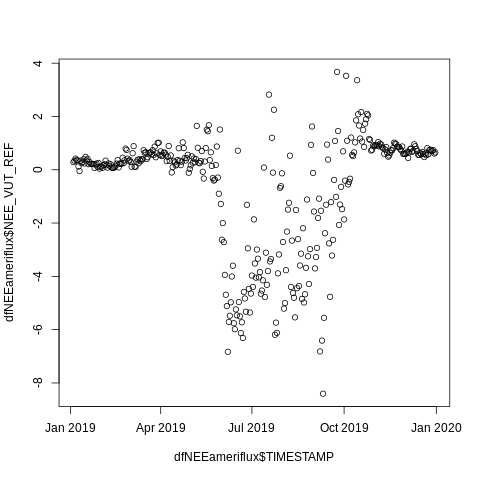

In [ ]:
%%R
# We will filter the NEE data, specifically the NEE_VUT_REF, where VUT is the Variable Ustar Threshold
# and reference selected on the basis of the model efficiency (MEF)

dfNEEameriflux <- dfDataFlux[lubridate::year(dfDataFlux$TIMESTAMP) == 2019, c("TIMESTAMP","NEE_VUT_REF")]

# convert units to gC m^-2 d^-1
dfNEEameriflux$NEE_VUT_REF <- dfNEEameriflux$NEE_VUT_REF * umol_per_s_gc_per_d
#plot
plot(dfNEEameriflux$TIMESTAMP, dfNEEameriflux$NEE_VUT_REF)


### Spatialized flux measurements

We are going to bring in data from Spatialeddy. Spatialeddy maps are created by running fluxes backwards on the wind to their geographic sources and thus providing a separation of spatial and temporal controls. We will see how a flux timeseries made of the mean of spatial flux data compares to the flux tower timeseries and other upscaled flux datasets.

In [ ]:
%%R
# Now, we will load a spatialized map of NEE flux from the SpatialEddy group.
library(terra)

# Download a single day (2019-07-01 for this test - feel free to experiment) along with the corresponding quality layer
flux <- terra::rast("https://storage.googleapis.com/data-benchflux/TREE/fluxCo2/tree_fluxCo2_20190701.tif")
qa <- terra::rast("https://storage.googleapis.com/data-benchflux/TREE/fluxCo2/tree_fluxCo2_20190701_qa.tif")

# Each day has 48 half-hourly layers. We can confirm this, along with spatial resolution and CRS:
cat("CRS:\n", terra::crs(flux), "\n\n")
cat("Extent:\n"); print(terra::ext(flux))
cat("\nLayers:", terra::nlyr(flux), "\n")
cat("\nCell Size:", terra::res(flux), "\n")



CRS:
 PROJCRS["WGS 84 / UTM zone 16N",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4326]],
    CONVERSION["UTM zone 16N",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-87,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.9996,
            SCALEUNIT["unity",1],
            ID["EPSG",8805]],
        PARAMETER["False easting",500000,
            LENGTHUNIT["metre",1],
            ID["EPSG",8806]],
        PARAMETER["False northing",0,
            LENGTHUNIT["metre",1],
            ID["EP

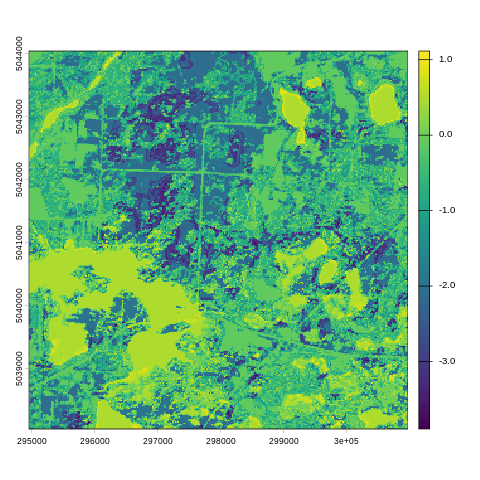

In [ ]:
%%R
# Now, we plot the first slice of the NEE and qa rasters side-by-side to show spatial patterns in flux and quality.
# The first time slice is 00:00:00 UTC. Try other time slices, e.g. flux$`2019-07-01T24:00:00Z` see how spatial patterns compare for different times of day?
# You can also load different days of the year (2019-2020) by changing the file paths in the cell above
#

flux1 <- flux$`2019-07-01T00:00:00Z`
qa1   <- qa$`2019-07-01T00:00:00Z`

# Plot the NEE and qa side-by-side
# layout(matrix(1:2, 1, 2))
plot(flux1)
# plot(qa1, main = "QA")
# layout(1)

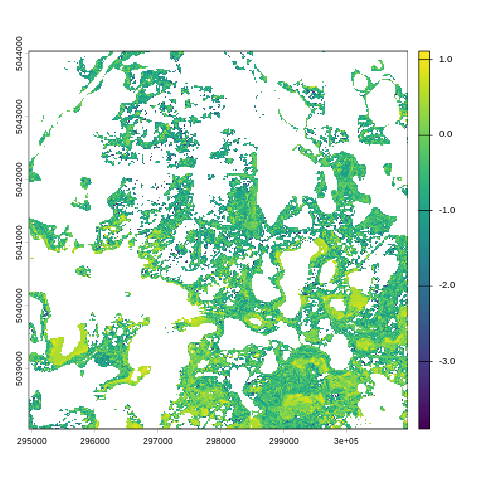

In [ ]:
%%R

# We will use the quality layer to mask out pixels. Below, we have chosen to keep all pixels with quality level 0, the lowest uncertainty.
# A pixel, aggragated to a day, with qa = 0 has 5% systematic uncertainty and 80% random uncertainty. Grouping n pixels decreases random uncertainty with a power law.

maskvalues <- c(0,1,2,3,4,5,6)[2:6] # change to show other uncertainty masks
maskedFlux <- terra::mask(flux1, qa1, maskvalues = maskvalues)

# plot the masked map
terra::plot(maskedFlux)



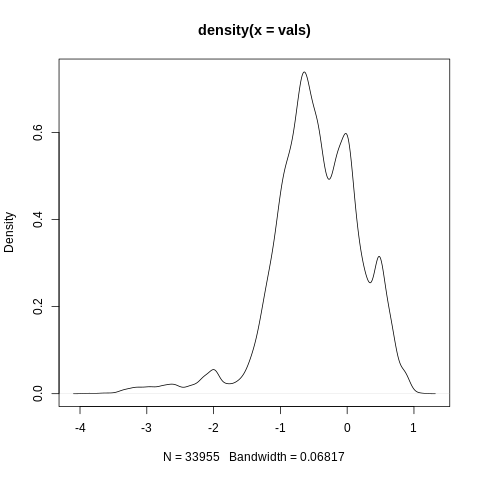

In [ ]:
%%R

# We are going to calculate the spatial mean of this time slice

# first extract the pixel values
vals <- terra::values(maskedFlux, na.rm = TRUE)

# calculate the spatial mean
flux_mean <- mean(vals)
flux_mean

# We can visualize spatial variability as a probibility density.
# Below we plot a density plot of flux values from the July 01 utc00:00:00 flux map we opened above
plot(density(vals))

# try this with different times of day

### How do the spatial maps compare to the flux timeseries?

To save time, we have pre-calculated the spatial statistics above for each fluxmap in the year of 2019 at the Treehaven site.

We will first aggregate the half-hours into daily means to compare with the Ameriflux data we downloaded earlier.

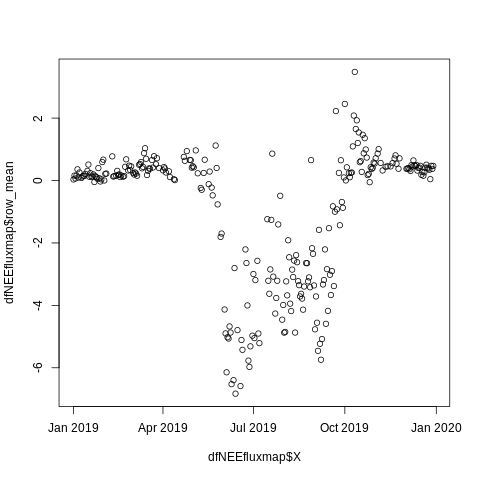

In [ ]:
%%R
dfNEEfluxmap <- read.csv(
    "/content/drive/Shared drives/2025 Workshop RS-FL upscaling - hand-on session/Tutorials/2. Interfacing flux scaling approaches across space and time/Material/2019_tree_NEE_mean.csv")

# (TABLE CLEANING)
# Format the dates for plotting
dfNEEfluxmap$X <- as.Date(as.character(dfNEEfluxmap$X), format = "%Y%m%d")

# Create a new column with the row mean
dfNEEfluxmap$row_mean <- rowMeans(
  dfNEEfluxmap[ , !(names(dfNEEfluxmap) %in% "X")],
  na.rm = TRUE
)

# View result
# head(NEEfluxmap2019$row_mean)
# convert units to gC m^-2 d^-1
dfNEEfluxmap$row_mean <- dfNEEfluxmap$row_mean * umol_per_s_gc_per_d

# plot
plot(dfNEEfluxmap$X, dfNEEfluxmap$row_mean,
     type = "p")


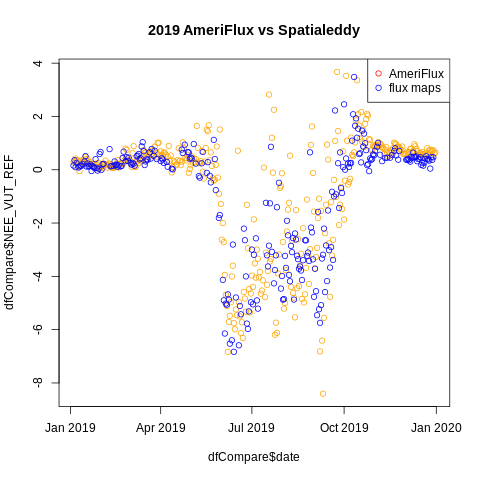

In [ ]:
%%R

# Merge the Ameriflux and spatial eddy dataframes by matching dates
dfNEEameriflux$date     <- as.Date(dfNEEameriflux$TIMESTAMP)
dfCompare <- merge(dfNEEameriflux, dfNEEfluxmap,
                   by.x = "date",
                   by.y = "X",
                   all = FALSE)

# Set y-axis limits based on the data
yl <- c(min(dfCompare$NEE_VUT_REF, dfCompare$row_mean, na.rm = TRUE), max(dfCompare$NEE_VUT_REF, dfCompare$row_mean, na.rm = TRUE))

# Plot
plot(dfCompare$date, dfCompare$NEE_VUT_REF,
     type = "p",
     ylim = yl,
     main = "2019 AmeriFlux vs Spatialeddy",
     col = "orange"
)
points(dfCompare$date, dfCompare$row_mean,
      type = "p",
      col = "blue"
)
legend("topright", legend = c("AmeriFlux", "flux maps"), col = c("red", "blue"), pch = 1)

## Add Eco2Bench and X-base modeled NEE

X-BASE is a water and carbon dataset from the FLUXCOM-X upscaling framework

In [ ]:
%%R
# Aggregate flux timeseries from ameriflux and spatialeddy to monthly means to align with Eco2Bench and X-base
dfCompare$month <- format(dfCompare$date, "%Y-%m")
dfMonth <- aggregate(cbind(NEE_VUT_REF, row_mean) ~ month,
                     data = dfCompare,
                     FUN = mean,
                     na.rm = TRUE)

# Convert month string to a Date (first day of each month)
dfMonth$month_date <- as.Date(paste0(dfMonth$month, "-01"))

In [ ]:
%%R
# Load the X-BASE monthly data from Google drive
install.packages('ncdf4')
library(ncdf4)
library(lubridate)

nc <- nc_open(
    "/content/drive/Shared drives/2025 Workshop RS-FL upscaling - hand-on session/Tutorials/2. Interfacing flux scaling approaches across space and time/Material/xbase_neon5sites_2019_MM.nc")

nee  <- ncvar_get(nc, "NEE")
site <- ncvar_get(nc, "site")
time <- ncvar_get(nc, "time")

origin <- sub("days since ", "", nc$dim$time$units)
dates  <- as.Date(time, origin = substr(origin, 1, 10))

nc_close(nc)

# long/tidy dataframe
dfNEExbase <- data.frame(
  SITE_ID = rep(site, times = length(dates)),
  date    = rep(dates, each = length(site)),
  NEE     = as.vector(nee)
)
dfNEExbase <- subset(dfNEExbase, SITE_ID == "TREE")

# Create a consistent plotting date (first day of month)
dfNEExbase$month_date <- as.Date(format(dfNEExbase$date + 1, "%Y-%m-01"))


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ncdf4_1.24.tar.gz'
Content type 'application/x-gzip' length 126032 bytes (123 KB)
downloaded 123 KB


The downloaded source packages are in
	‘/tmp/RtmpXGGQ4t/downloaded_packages’


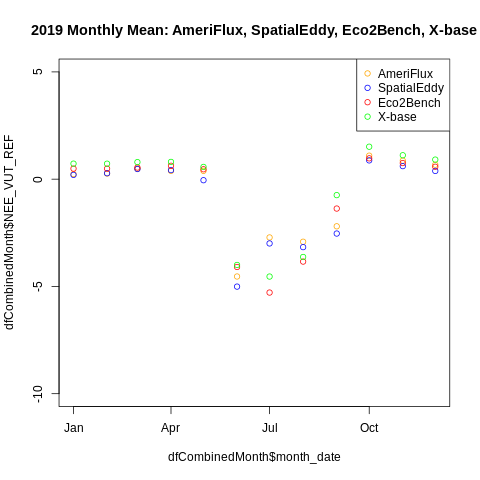

In [ ]:
%%R
# Read Eco2Bench precalculated dataset from google drive.
# We extracted NEE values from within the Treehaven study area defined by the spatialeddy extent
dfeco2 <- read.csv(
  '/content/drive/Shared drives/2025 Workshop RS-FL upscaling - hand-on session/Tutorials/2. Interfacing flux scaling approaches across space and time/Material/NEON_sites_NEE_GPP_prediction_2019_2024.csv')
dfeco2NEE <- subset(dfeco2,
                    SITE_ID == "US-xTR" &
                      year == 2019 & # Change year to 2019 to match other datasets
                      model_name == "NEE_Baseline" &
                      type == "pred")

# Create a month_date column for dfeco2NEE
dfeco2NEE$month_date <- as.Date(paste0(dfeco2NEE$year, "-", dfeco2NEE$month, "-01"))

# Merge AmeriFlux & SpatialEddy table with Eco2bench
dfCombinedMonth <- merge(dfMonth, dfeco2NEE, by = "month_date", all = TRUE)

# Merge xbase results with the other datasets
dfCombinedMonth <- merge(dfCombinedMonth, dfNEExbase, by.x = "month_date", by.y = "month_date", all = TRUE)

# Set y-axis limits
yl_combined <- c(-10, 5)

# Plot all four
plot(dfCombinedMonth$month_date, dfCombinedMonth$NEE_VUT_REF,
     type = "p",
     ylim = yl_combined,
     main = "2019 Monthly Mean: AmeriFlux, SpatialEddy, Eco2Bench, X-base",
     col = "orange")
points(dfCombinedMonth$month_date, dfCombinedMonth$row_mean,
       type = "p",
       col = "blue")
points(dfCombinedMonth$month_date, dfCombinedMonth$value,
       type = "p",
       col = "red")
points(dfCombinedMonth$month_date, dfCombinedMonth$NEE,
       type = "p",
       col = "green")
legend("topright", legend = c("AmeriFlux", "SpatialEddy", "Eco2Bench", "X-base"),
       col = c("orange", "blue", "red", "green"), pch = 1)


#### Question: How does variability in NEE between datasets compare to the flux's variability in space in a flux map?

Look at the variability in NEE between datasets over the same study area above. Where do you think some of this variability comes from?

We are now going to plot an approximation of spatial variability within the study site, derived from the spatial standard deviation from the spatialeddy dataset.

In [ ]:
%%R

# we precalculated and pre-aggragated this metric the same way as the spatialeddy mean timeseries above
# read in the file from drive
dfNEEseVar <- read.csv(
    "/content/drive/Shared drives/2025 Workshop RS-FL upscaling - hand-on session/Tutorials/2. Interfacing flux scaling approaches across space and time/Material/2019_tree_NEE_sd_MM.csv")

# Ensure month_date is of Date type in dfNEEseVar before merging
dfNEEseVar$month_date <- as.Date(dfNEEseVar$month_date)

# Merge with the larger table that stores the other NEE means
dfCombinedMonth <- merge(dfCombinedMonth, dfNEEseVar, by.x = "month_date", all = TRUE)

# we will calculate a spatial envelope from the standard deviation. We use 2.33 as a z-score
# multiplier to get the distance from the mean to the 1st and 99th percentile
# names(dfCombinedMonth)
dfCombinedMonth$envelope_bottom <- dfCombinedMonth$row_mean - (dfCombinedMonth$spatial_sd_daily_mean * 2.33)
dfCombinedMonth$envelope_top <- dfCombinedMonth$row_mean + (dfCombinedMonth$spatial_sd_daily_mean * 2.33)


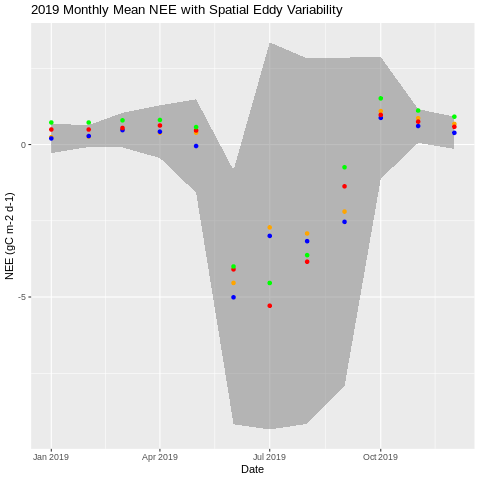

In [ ]:
%%R
library(ggplot2)

d <- dfCombinedMonth[order(dfCombinedMonth$month_date), ]

ggplot(d, aes(x = month_date)) +
  geom_ribbon(aes(ymin = envelope_bottom, ymax = envelope_top),
              fill = "grey50", alpha = 0.5) +
  geom_point(aes(y = NEE_VUT_REF), color = "orange") +
  geom_point(aes(y = row_mean),    color = "blue") +
  geom_point(aes(y = value),       color = "red") +
  geom_point(aes(y = NEE),         color = "green") +
  labs(title = "2019 Monthly Mean NEE with Spatial Eddy Variability",
       x = "Date", y = "NEE (gC m-2 d-1)")


### Conclusion and potential application projects

These are interesting results. NEE is much more variable within the Treehaven site than it is between datasets.

How might we use this additional spatial information from spatialized fluxes to tie bottom-up eddy covarience measurements to top-down global NEE models?


Below is a figure from BenchFlux where we show modeled GPP from CARBON-GEM vs. Ameriflux and Eco2bench, where spatial variability dominates in the growing season and model uncertainty dominates in the leaf-off season. Dealing with uncertainty in the spatialeddy is an interesting topic. How can we use site-level uncertainty to make spatialized flux maps more defensible for stakeholders?

We did not show other BenchFlux datasets. For example, ALIVE upscaled GPP predicts near-real-time 5-min fluxes over CONUS. https://alive-abi.github.io/alive/index.html.  



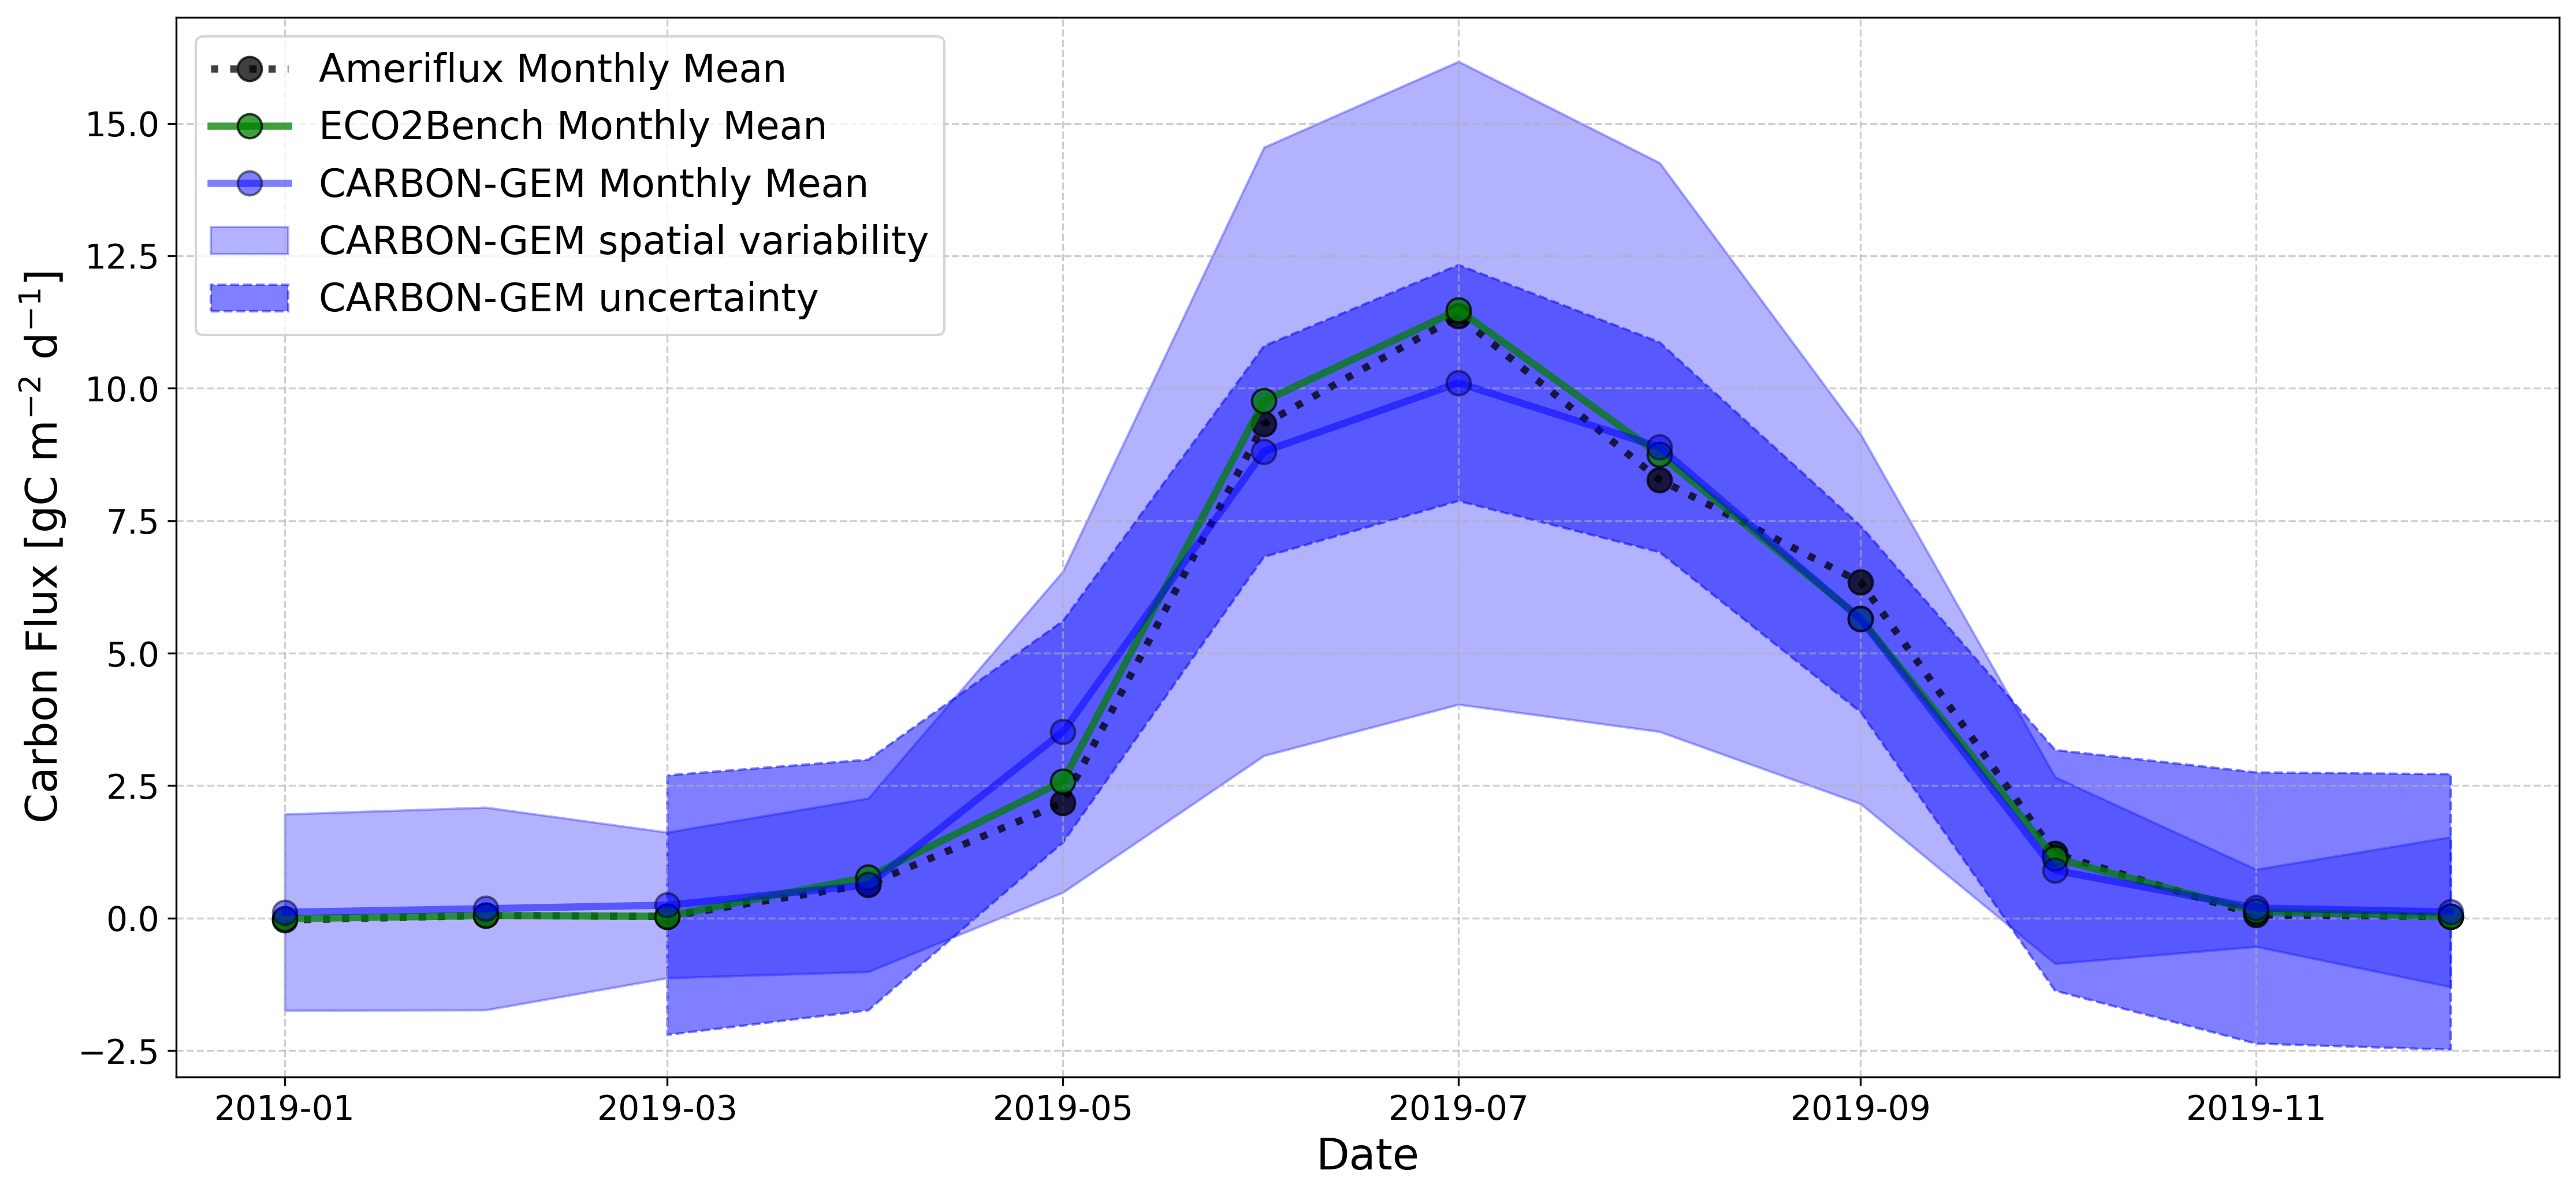